In [1]:
import os
os.environ["JAX_PLATFORMS"] = 'cpu'
import jax.numpy as jnp
import jax 
import numpy as np
from utils import (
                  syn_group_id_paths_for_sem_data,
                  sem_ids_path,
                  syn_syn_ids_path,
                  collect_data,
                   torch_to_jax,
                   clip,
                   flatten_tokens_features,
                   depths,
                   reduce_list_half_preserve_extremes,
                   remove_syn_group_averages,
                   load_and_subtract_syn_group_averages,
                   )
from geometry import normalized_L2_distance
from datapaths import * 
import matplotlib.pyplot as plt
from torch import from_numpy


def compute_rowwise_cosine_similarity(act_A, act_B, eps=1e-8):
    """
    Compute row-wise cosine similarity between two activation matrices.

    Args:
        act_A (jnp.ndarray): shape (N, D), activations from space A
        act_B (jnp.ndarray): shape (N, D), activations from space B
        eps (float): small constant to avoid division by zero

    Returns:
        jnp.ndarray: shape (N,), cosine similarities for each row pair
    """
    numerator = jnp.sum(act_A * act_B, axis=1)
    denominator = jnp.linalg.norm(act_A, axis=1) * jnp.linalg.norm(act_B, axis=1)
    return numerator / (denominator + eps)


/home/acevedo/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
min_token_length = 6
n_tokens = min_token_length
n_files = 21
model_name = 'qwen7b'
precision = 32
data_var = 'sem'
avg_tokens = 0

input_path_A = input_paths['english'][model_name]['matching']['0'][data_var]
input_path_B = input_paths['english'][model_name]['matching']['1'][data_var]

In [3]:
all_activations_A = collect_data(input_path_A, 
            min_token_length, 
            n_files,
            model_name,
            avg_tokens,
            )
all_activations_B = collect_data(input_path_B, 
            min_token_length, 
            n_files,
            model_name,
            avg_tokens,
            )

qwen7b dtype: torch.bfloat16


Collect File: 100%|██████████| 21/21 [00:01<00:00, 11.02it/s]


all_hidden_states["layer_0"].shape=torch.Size([2018, 6, 3584])
importing took 0.05133358637491862 m
qwen7b dtype: torch.bfloat16


Collect File: 100%|██████████| 21/21 [00:01<00:00, 17.99it/s]


all_hidden_states["layer_0"].shape=torch.Size([2018, 6, 3584])
importing took 0.039299329121907554 m


In [4]:
def preprocessing(all_activations, layer, space_index, syntax_center_flag, global_center_flag, removal_method):

  center_A_flag = syntax_center_flag
  center_B_flag = center_A_flag

  syn_syn_indices = jnp.array(np.loadtxt(syn_syn_ids_path,dtype=int),dtype=jnp.int32) # filtering data to ALSO have their syntax group in space B

  # act = {}
  # centers = {}
  # global_center = {}

  # loading data
  _all_activations = all_activations[f"layer_{layer}"]
  act = torch_to_jax(_all_activations[:,-n_tokens:,:],precision)
  act = flatten_tokens_features(act)

  # globally centering data [with all samples]
  if global_center_flag:
      global_center = jnp.mean(act,axis=0)
      act = act - jnp.broadcast_to(global_center,act.shape)
  else:
      global_center = None
  
  # keeping data with syn_centers
  sem_ids = jnp.array(np.loadtxt(sem_ids_path,dtype=int),dtype=jnp.int32) # filtering data to have their syntax group in space A 
  act = act[sem_ids]

  # loading syntax_centers
  centers_folder = f"/home/acevedo/syn-sem/results/global_centering_0/spaces_AB/similarity_fn_normalized_L2_distance/precision_32/language_english/data_var_syn/modelA_qwen7b/modelB_qwen7b/match_var_matching/n_files_21/min_token_length_6/similarities/centers_syn/Nbits_0/n_tokens_{n_tokens}/avg_tokens_0/batch_shuffle_0/layer_A_{layer}/layer_B_{layer}/"
  centers = jnp.array(np.load(os.path.join(centers_folder, f'syn_centers_{space_index}.npy'))).astype(jnp.float32) #(num_groups,E)

  # # global_centering syntax centers...
  if global_center_flag: 
      centers = centers - jnp.broadcast_to(global_center,centers.shape)
  
  if syntax_center_flag:
    if space_index == 'A': # for 'A', first centering, then filtering
      act = load_and_subtract_syn_group_averages(act,syn_group_id_paths_for_sem_data[space_index],centers_folder,center_A_flag,removal_method,global_center,space_index)
      act = act[syn_syn_indices]

  if space_index == 'B': # for 'B', first filtering, then centering
    if syntax_center_flag:
      act = act[syn_syn_indices]
      act = load_and_subtract_syn_group_averages(act,syn_group_id_paths_for_sem_data[space_index],centers_folder,center_B_flag,removal_method,global_center,space_index)

  # print(f'{act.shape=}')
  # print(f'{centers.shape=}')
  # if global_center_flag:
  #   print(f'{global_center.shape=}')

  return act, centers, global_center

loading and subtracting syn group averages
loading and subtracting syn group averages
loading and subtracting syn group averages
loading and subtracting syn group averages
loading and subtracting syn group averages
loading and subtracting syn group averages


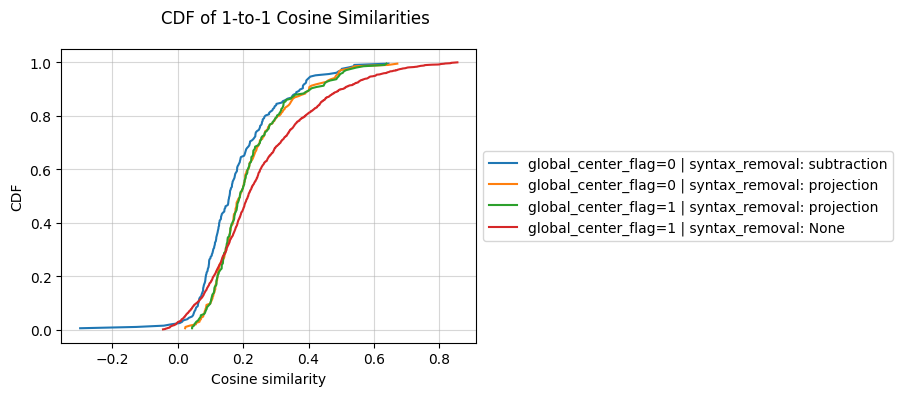

In [5]:
def plot_cdf(data, label, **kwargs):
    """Plot empirical CDF of data."""
    sorted_data = np.sort(data)
    cdf = np.arange(1, len(sorted_data)+1) / len(sorted_data)
    plt.plot(sorted_data, cdf, label=label, **kwargs)


# layers = [14] # reduce_list_half_preserve_extremes(np.arange(1,depths[model_name]+1,dtype=int))
layer = 14

fig, ax = plt.subplots(figsize=(6,4))

params = [
          (1,0,'subtraction',0),
          (1,0,'projection',0),
          # (1,1,'subtraction',0),
          (1,1,'projection',0),
          (0,1,None,0),
          # (0,1,None,1),
          ]
for syntax_center_flag, global_center_flag, removal_method, batch_shuffle_B in params:

  act_A, centers_A, global_center_A = preprocessing(
      all_activations_A, layer, space_index='A',
      syntax_center_flag=syntax_center_flag,
      global_center_flag=global_center_flag,
      removal_method=removal_method,
  )
  act_B, centers_B, global_center_B = preprocessing(
      all_activations_B, layer, space_index='B',
      syntax_center_flag=syntax_center_flag,
      global_center_flag=global_center_flag,
      removal_method=removal_method,
  )

  act_B_curr = act_B
  if batch_shuffle_B:
      key = jax.random.PRNGKey(9999)  # seed
      perm = jax.random.permutation(key, act_B.shape[0])
      act_B_curr = act_B[perm]

  # Compute rowwise cosine similarities
  cosine_sims = compute_rowwise_cosine_similarity(act_A, act_B_curr)
  cosine_sims_np = np.asarray(cosine_sims)  # move to numpy

  lbl = f'{global_center_flag=} '
  lbl += f'| syntax_removal: {removal_method}'
  plot_cdf(cosine_sims_np, lbl)

plt.xlabel("Cosine similarity")
plt.ylabel("CDF")
plt.suptitle("CDF of 1-to-1 Cosine Similarities")
plt.grid(alpha=0.5)
plt.tight_layout()

box = ax.get_position()
ax.set_position([box.x0, box.y0, box.width * 0.8, box.height])
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))

plt.show()


In [6]:
"""On the cosine similarities:

setup: 

A = english sentences 
B = english paraphrases

I compute the 1-to-1 cosine similarities between them (matching meaning)

In blue, syntax_centered data with subtractions
In orange,  syntax_centered data with projections 
In green, I remove syntax projections after global centering. 
In red, I just do the global centering, no syntax centering.

Red gives indeed the maximal similarities"""

'On the cosine similarities:\n\nsetup: \n\nA = english sentences \nB = english paraphrases\n\nI compute the 1-to-1 cosine similarities between them (matching meaning)\n\nIn blue, syntax_centered data with subtractions\nIn orange,  syntax_centered data with projections \nIn green, I remove syntax projections after global centering. \nIn red, I just do the global centering, no syntax centering.\n\nRed gives indeed the maximal similarities'